# Apprentice Risk Scoring - exploration

Goal: prototype and sense-check a transparent, rules-based risk score
for flagging apprentices who may need support, using synthetic data.

This is deliberately **not** a trained ML model. A trained model needs
real recorded outcomes (EPA fail, withdrawal, Break in Learning) as its
target, which take months to accumulate and don't exist yet for real
apprentices. `calculate_risk_score.py` (imported below) is the single
source of truth for the current weights and caps - update that file,
not this notebook, when the formula changes.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

In [7]:
df = pd.read_csv("synthetic_apprentice_risk_data.csv")
df["lldd_flag"] = df["lldd_flag"].astype(int)
print(df.shape)
df.head()

(266, 12)


,synthetic_apprentice_id,cohort,attendance_pct,days_since_last_mentoring,days_since_last_progress_review,otj_deficit_hours,fs_maths_status,fs_english_status,lldd_flag,days_since_onefile_update,assignments_late_count,assignments_outstanding_count
0,SYN-001,MLE01,100.0,20,42,55.0,achieved,achieved,0,11,0,0
1,SYN-002,DA09,96.0,10,22,-5.0,achieved,in_progress,1,17,0,0
2,SYN-003,DT10,78.0,35,40,18.0,achieved,not_required,0,16,1,1
3,SYN-004,DA01,92.0,150,160,2.0,achieved,not_required,0,21,0,0
4,SYN-005,DA08,45.0,100,120,60.0,in_progress,achieved,0,18,5,3


## 1. EDA

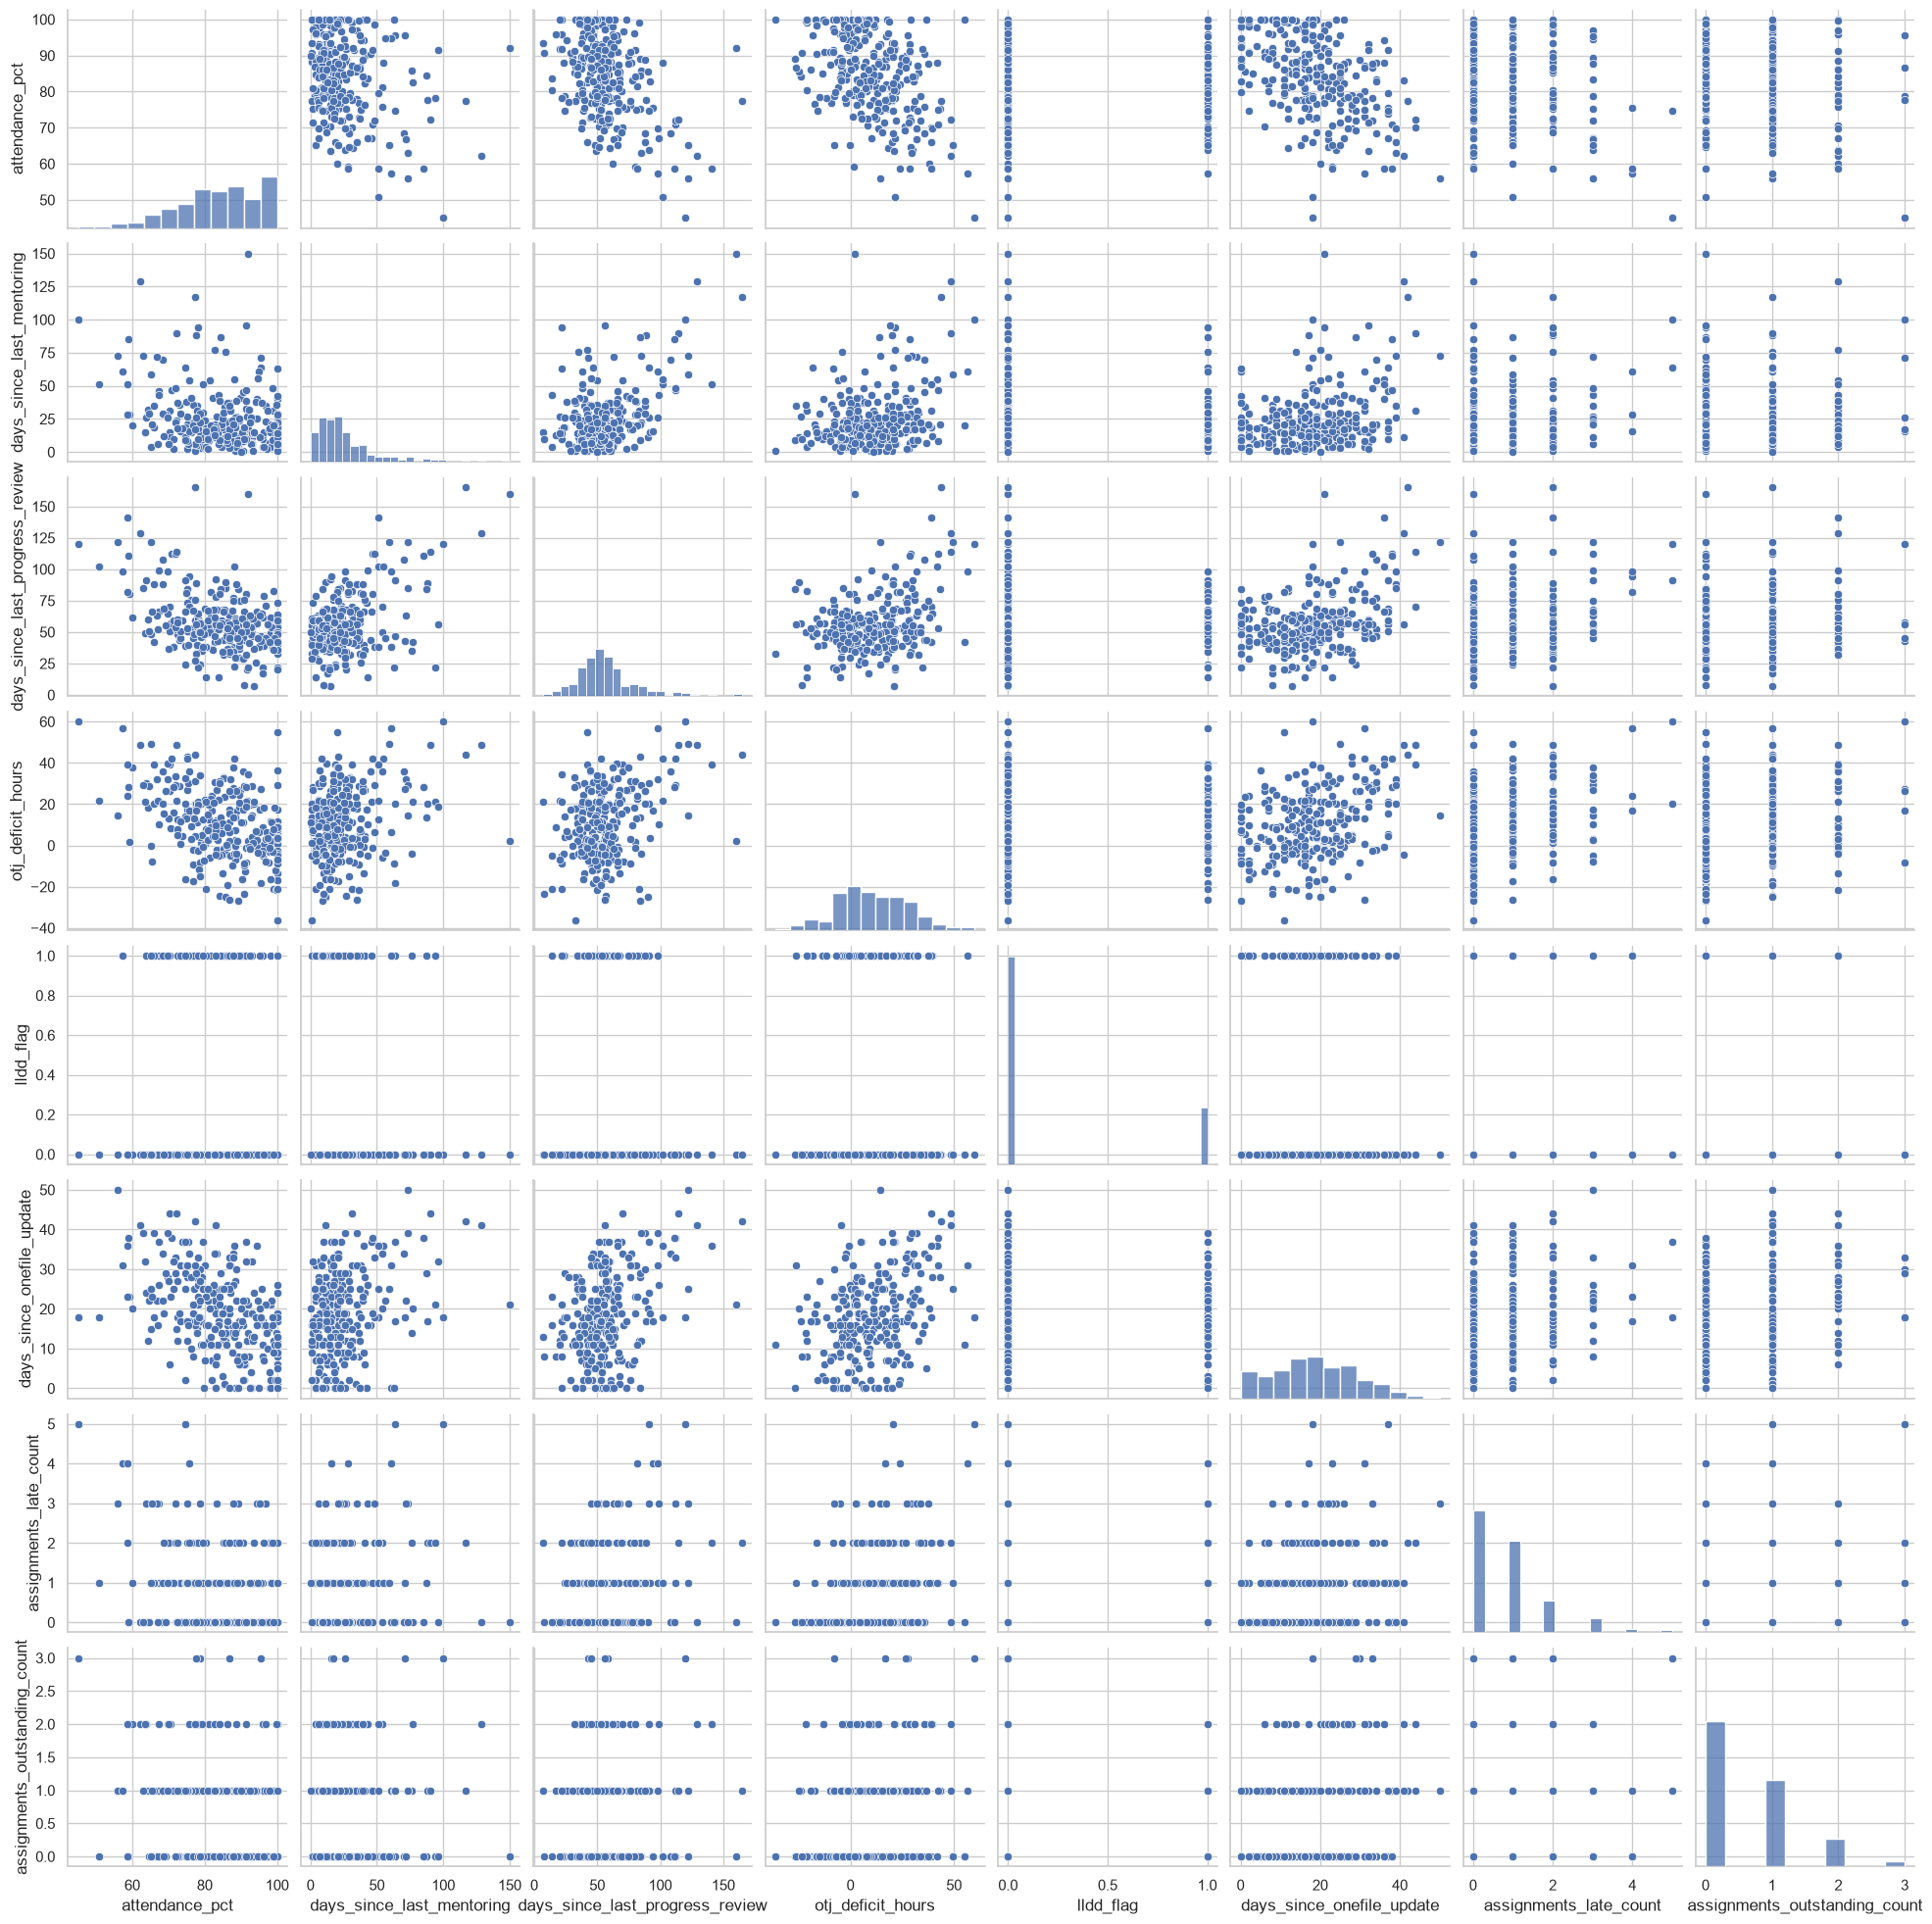

In [8]:
sns.pairplot(df)

In [9]:
print(df.isna().sum().sum(), "missing values total")
print()
print(df.select_dtypes(include=np.number).describe().T)

0 missing values total

                                 count       mean        std   min    25%    50%     75%    max
attendance_pct                   266.0  84.043233  11.250542  45.0  77.05  85.05  92.625  100.0
days_since_last_mentoring        266.0  25.206767  22.704137   0.0  11.00  19.00  31.000  150.0
days_since_last_progress_review  266.0  56.992481  23.367611   7.0  43.00  54.00  65.750  165.0
otj_deficit_hours                266.0  10.828195  16.971290 -36.2  -0.85  10.00  21.475   60.0
lldd_flag                        266.0   0.214286   0.411099   0.0   0.00   0.00   0.000    1.0
days_since_onefile_update        266.0  18.586466  10.531267   0.0  11.25  18.00  25.000   50.0
assignments_late_count           266.0   0.827068   0.994409   0.0   0.00   1.00   1.000    5.0
assignments_outstanding_count    266.0   0.593985   0.752732   0.0   0.00   0.00   1.000    3.0


## 2. Risk scoring

### Weights

Imported from `calculate_risk_score.py`. Current values - OTJ deficit
weighted much higher, assignments outstanding/late weighted somewhat
higher, everything else scaled down to compensate so the total still
sums to 1:

| Factor | Weight |
|---|---|
| OTJ deficit | 0.350 |
| Assignments outstanding | 0.190 |
| Assignments late | 0.190 |
| Attendance % | 0.098 |
| Days since OneFile update | 0.061 |
| Days since last mentoring | 0.049 |
| Days since last progress review | 0.037 |
| FS English status | 0.012 |
| FS Maths status | 0.012 |

### What the caps do

Each factor is on a different scale (OTJ deficit in hours, attendance in %,
assignments as a count), so they can't be weighted together directly - the
weights would be swamped by whichever factor happens to use the biggest
numbers. The caps fix this by converting each raw value into a 0-1
"concern" score before weighting.

Each cap answers: **at what point does this factor count as maximum
concern?** Everything from 0 up to the cap scales proportionally into
0-1. Anything past the cap is still just treated as 1.0 (max concern),
not higher - otherwise one extreme outlier could dominate the whole
score and drown out the other eight factors.

The cap value itself is a judgement call, same as the weights - a lower
cap means that factor reaches "maximum concern" faster (more people
flagged sooner), a higher cap means it takes more to max out (fewer
people flagged, only the most extreme cases).

In [10]:
from calculate_risk_score import calculate_risk_score, WEIGHTS, CAPS, FS_STATUS_CONCERN

# For EDA only - calculate_risk_score() handles this mapping internally,
# these columns just make the raw concern level visible/plottable below
df["fs_english_numeric"] = df["fs_english_status"].map(FS_STATUS_CONCERN)
df["fs_maths_numeric"] = df["fs_maths_status"].map(FS_STATUS_CONCERN)

In [11]:
scored = calculate_risk_score(df)

print(scored["risk_band"].value_counts())
scored.sort_values("risk_score", ascending=False).head(20)

risk_band
Low       186
Medium     74
High        6
Name: count, dtype: int64


,synthetic_apprentice_id,cohort,attendance_pct,days_since_last_mentoring,days_since_last_progress_review,otj_deficit_hours,fs_maths_status,fs_english_status,lldd_flag,days_since_onefile_update,assignments_late_count,assignments_outstanding_count,fs_english_numeric,fs_maths_numeric,risk_score,risk_band
4,SYN-005,DA08,45.0,100,120,60.0,in_progress,achieved,0,18,5,3,0.0,0.5,0.836,High
173,SYN-174,DT02,57.3,61,98,56.6,not_required,not_required,1,31,4,1,0.0,0.0,0.729,High
116,SYN-117,MLE02,72.3,90,114,48.6,not_required,in_progress,0,44,2,1,0.5,0.0,0.634,High
262,SYN-263,DT09,58.6,51,141,39.1,in_progress,not_required,0,36,2,2,0.0,0.5,0.612,High
41,SYN-042,DT05,62.1,129,129,48.5,not_required,in_progress,0,41,0,2,0.5,0.0,0.606,High
58,SYN-059,AI01,77.3,117,165,43.9,in_progress,in_progress,0,42,2,1,0.5,0.5,0.603,High
15,SYN-016,AI02,70.2,31,70,39.1,in_progress,in_progress,0,44,2,2,0.5,0.5,0.582,Medium
180,SYN-181,DA04,75.8,54,70,35.7,not_required,achieved,0,34,2,2,0.0,0.0,0.559,Medium
265,SYN-266,DA10,65.1,59,122,49.2,in_progress,not_required,0,25,1,0,0.0,0.5,0.559,Medium
93,SYN-094,DT03,75.2,21,84,43.2,not_required,in_progress,0,28,2,1,0.5,0.0,0.555,Medium


In [12]:
high_risk_true = scored[scored["risk_band"] == "High"]
high_risk_true[["synthetic_apprentice_id", "cohort", "risk_score", "risk_band"]]

,synthetic_apprentice_id,cohort,risk_score,risk_band
4,SYN-005,DA08,0.836,High
41,SYN-042,DT05,0.606,High
58,SYN-059,AI01,0.603,High
116,SYN-117,MLE02,0.634,High
173,SYN-174,DT02,0.729,High
262,SYN-263,DT09,0.612,High


## 3. Correlation between raw features

In [13]:
cols = ['attendance_pct', 'days_since_last_mentoring',
       'days_since_last_progress_review', 'otj_deficit_hours',
       'days_since_onefile_update', 'assignments_late_count',
       'assignments_outstanding_count']

corr_matrix = df[cols].corr()

<Axes: >

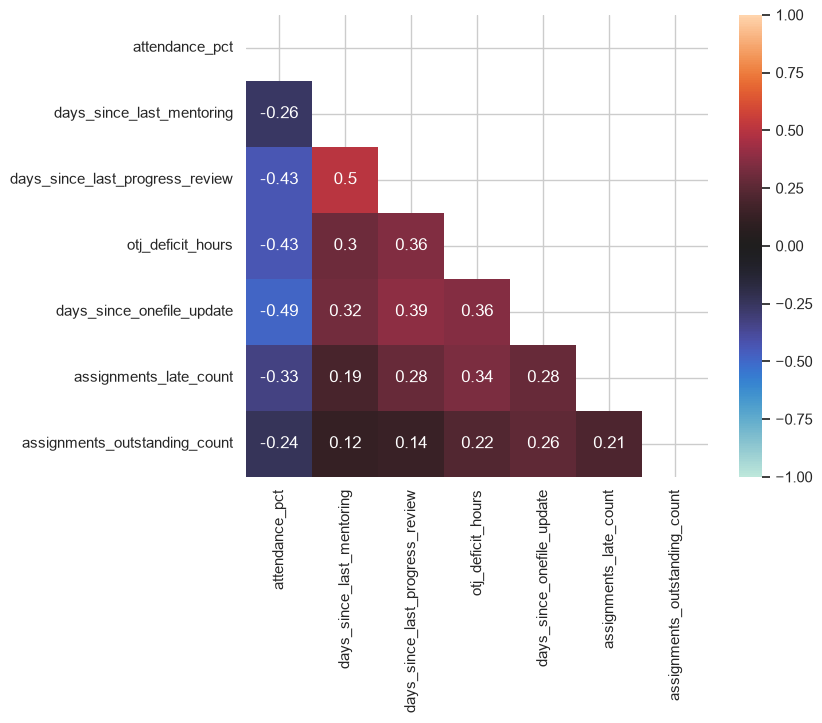

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, vmin=-1, vmax=1, center=0, square=True, mask=mask, ax=ax)

## 4. Explaining individual risk flags

For each High-risk apprentice, shows which factors are actually driving
their score (top 4 by weighted contribution) and marks the rest as
"Not a concern" - useful for a quick "why was this person flagged"
check during a caseload review.

In [19]:
FACTOR_COLUMNS = list(WEIGHTS.keys())

def top_factor_row(row, weights=None, caps=None, top_n=4):
    weights = weights or WEIGHTS
    caps = caps or CAPS
    components = {
        "attendance_pct": (100 - row["attendance_pct"]) / 100,
        "otj_deficit_hours": np.clip(max(row["otj_deficit_hours"], 0) / caps["otj_deficit_hours"], 0, 1),
        "assignments_outstanding_count": np.clip(row["assignments_outstanding_count"] / caps["assignments_outstanding_count"], 0, 1),
        "assignments_late_count": np.clip(row["assignments_late_count"] / caps["assignments_late_count"], 0, 1),
        "days_since_onefile_update": np.clip(row["days_since_onefile_update"] / caps["days_since_onefile_update"], 0, 1),
        "days_since_last_mentoring": np.clip(row["days_since_last_mentoring"] / caps["days_since_last_mentoring"], 0, 1),
        "days_since_last_progress_review": np.clip(row["days_since_last_progress_review"] / caps["days_since_last_progress_review"], 0, 1),
        "fs_maths_status": FS_STATUS_CONCERN[row["fs_maths_status"]],
        "fs_english_status": FS_STATUS_CONCERN[row["fs_english_status"]],
    }
    contributions = pd.Series({k: weights[k] * v for k, v in components.items()}).sort_values(ascending=False)
    top_factors = set(contributions.head(top_n).index)

    return pd.Series({factor: (row[factor] if factor in top_factors else "Not a concern") for factor in FACTOR_COLUMNS})

high_risk = scored[scored["risk_band"] == "High"].copy()
factor_cols = high_risk.apply(top_factor_row, axis=1).add_suffix("_flagged")
high_risk = pd.concat([high_risk, factor_cols], axis=1)
high_risk = high_risk.sort_values("risk_score", ascending=False)

display_cols = ["synthetic_apprentice_id", "cohort", "risk_score", "risk_band"] + list(factor_cols.columns)
print(high_risk[display_cols].to_string(index=False))

synthetic_apprentice_id cohort  risk_score risk_band  otj_deficit_hours_flagged assignments_outstanding_count_flagged assignments_late_count_flagged attendance_pct_flagged days_since_onefile_update_flagged days_since_last_mentoring_flagged days_since_last_progress_review_flagged fs_english_status_flagged fs_maths_status_flagged
                SYN-005   DA08       0.836      High                       60.0                                     3                              5                   45.0                     Not a concern                     Not a concern                           Not a concern             Not a concern           Not a concern
                SYN-174   DT02       0.729      High                       56.6                         Not a concern                              4          Not a concern                                31                                61                           Not a concern             Not a concern           Not a concern
          